# Foundations NLP Block Course Assignment

Train and evaluate character-level GPT model on small Shakespeare dataset using nanoGPT

Student Names: Alexis Liston, Isabel Sittner
Course: Foundations of NLP
WiSe 25/26

## Notebook Outline
1. Environment setup and verification
2. Baseline trianing
3. Experiment with hyperparameters
4. Plots

### 1. Environment Setup and Verification

In [1]:
# verify environment setup

import sys
import torch
import numpy as np

print(f"Python version: {sys.version.split()[0]}")
print(f"PyTorch version: {torch.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
    print(f"CUDA version (PyTorch): {torch.version.cuda}")

Python version: 3.11.15
PyTorch version: 2.11.0+cu130
NumPy version: 2.4.3
CUDA available: True
CUDA device: NVIDIA RTX A1000 6GB Laptop GPU
CUDA version (PyTorch): 13.0


In [2]:
# verify correct working directory and folders

import os
print(f"Current working directory: {os.getcwd()}")
print(f"train.py exists: {os.path.exists('train.py')}")
print(f"data/shakespeare_char/train.bin exists: {os.path.exists('data/shakespeare_char/train.bin')}")
print(f"logs/ exists: {os.path.exists('logs')}")
print(f"config/ exists: {os.path.exists('config')}")

Current working directory: c:\Users\lexil\code\NLP Foundations Assignment\FoundationsNLP
train.py exists: True
data/shakespeare_char/train.bin exists: True
logs/ exists: True
config/ exists: True


Prepare the dataset before baseline training (this creates the train.bin and val.bin files, the tokenized training and validation datasets)  
Run this in the terminal:

cd data/shakespeare_char  
python prepare.py  
cd ../.. 

### 2. Baseline Training

baseline training as specified in assignment. I'm using an NVIDIA RTX A100 GPU, so will set device = 'cuda'

In [6]:
%%writefile config/train_shakespeare_char_baseline.py
# baseline config file specified in assignment

out_dir = 'out-shakespeare-baseline'
eval_interval = 250
eval_iters = 200
log_interval = 10
always_save_checkpoint = False
wandb_log = False
wandb_project = 'nanoGPT-assignment'
wandb_run_name = 'baseline'
dataset = 'shakespeare_char'
gradient_accumulation_steps = 1
batch_size = 64
block_size = 256
n_layer = 6
n_head = 6
n_embd = 384
dropout = 0.2
learning_rate = 1e-3
max_iters = 5000
lr_decay_iters = 5000
min_lr = 1e-4
beta2 = 0.99
warmup_iters = 100
weight_decay = 1e-1
device = 'cuda' # using 'cuda' with GPU
compile = False # compiler has issues on Windows; leaving False

Overwriting config/train_shakespeare_char_baseline.py


In [ ]:
# run the baseline training
# pipe output to the notebook display and a log file (baseline.log) and track training runtime

import subprocess
import time

log_path = "logs/baseline.log"
cmd = ["python", "train.py", "config/train_shakespeare_char_baseline.py"]

start_time = time.time()

with open(log_path, "w", encoding="utf-8") as log_file:
    process = subprocess.Popen(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )
    for line in process.stdout:
        print(line, end="")          # live display in the notebook
        log_file.write(line)         # simultaneously write to log file
        log_file.flush()             # flush so the file updates in real time
    process.wait()

elapsed = time.time() - start_time
minutes, seconds = divmod(elapsed, 60)

summary = (
    f"\n--- Training finished with exit code {process.returncode} ---\n"
    f"Wall-clock time: {int(minutes)} min {seconds:.1f} sec ({elapsed:.1f} s total)\n"
)
print(summary)

# Append the timing to the log file so it's preserved alongside the training output
with open(log_path, "a", encoding="utf-8") as log_file:
    log_file.write(summary)

In [7]:
# Sample generation from the trained model

import subprocess

sample_output_path = "logs/baseline_samples.txt"
cmd = [
    "python", "sample.py",
    "--out_dir=out-shakespeare-baseline",
    "--device=cuda",
    "--num_samples=3",
    "--max_new_tokens=500",
]

with open(sample_output_path, "w", encoding="utf-8") as sample_file:
    process = subprocess.Popen(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )
    for line in process.stdout:
        print(line, end="")
        sample_file.write(line)
        sample_file.flush()
    process.wait()

print(f"\n--- Sampling finished with exit code {process.returncode} ---")
print(f"Samples saved to: {sample_output_path}")

Overriding: out_dir = out-shakespeare-baseline
Overriding: device = cuda
Overriding: num_samples = 3
Overriding: max_new_tokens = 500
number of parameters: 10.65M
Loading meta from data\shakespeare_char\meta.pkl...


ANGELO:
And cowards it be strawn'd; and you will grave you
gates your happiness, that by the shorten with me.

ISABELLA:
In gold time of it.

DUKE VINCENTIO:
Why, well, how that Hercules the former properioved me
else no more.

ANGELO:
Here's a minister.

ISABELLA:
I will answer the prisoner of the
most Capulet, prize on the dominion. I have
strange it for the king thrust for the great sheep-by allowers, and
she was a marble soldier.

ANGELO:
Had you a help?

ISABELLA:
A neither to change me to
---------------

Men pardon me, you shall have hanged to myself.

LORD FITZWATER:
The honour is so not unborn, whom comes off
Which mighty more should perjury of evils.

WARWICK:
Hence stays our father; but what makes the grounds
Of blood, against his sovereign news our household.



### 3. Hyperparameter Experiments

Starting with a resuable helper function to define funtions for running the train.py with the experiment configuration and generating text samples from the trained model with sample.py, capture run-time, live output display and saving log-files. This helps ensure consistency across experiments and avoids repeating the same boilerplate lines for each experiment.

In [3]:
# Helper function

import subprocess
import time
from pathlib import Path

def run_training(config_name):
    """
    Run a nanoGPT training experiment.
    
    Args:
        config_name: Name of the config file (without path or extension).
                     e.g. "train_shakespeare_char_lr1e2"
    
    The config file should exist at config/{config_name}.py
    Logs are saved to logs/{experiment_name}.log, where experiment_name
    is the config name with the 'train_shakespeare_char_' prefix stripped.
    """
    config_path = f"config/{config_name}.py"
    
    # give a short experiment name for the log file
    experiment_name = config_name.replace("train_shakespeare_char_", "")
    log_path = f"logs/{experiment_name}.log"
    
    print(f"{'='*60}")
    print(f"Experiment: {experiment_name}")
    print(f"Config:     {config_path}")
    print(f"Log:        {log_path}")
    print(f"{'='*60}\n")
    
    cmd = ["python", "train.py", config_path]
    start_time = time.time()
    
    with open(log_path, "w", encoding="utf-8") as log_file:
        process = subprocess.Popen(
            cmd,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True,
            bufsize=1,
        )
        for line in process.stdout:
            print(line, end="")
            log_file.write(line)
            log_file.flush()
        process.wait()
    
    elapsed = time.time() - start_time
    minutes, seconds = divmod(elapsed, 60)
    
    summary = (
        f"\n{'='*60}\n"
        f"Experiment '{experiment_name}' finished (exit code {process.returncode})\n"
        f"Wall-clock time: {int(minutes)} min {seconds:.1f} sec ({elapsed:.1f} s total)\n"
        f"{'='*60}\n"
    )
    print(summary)
    
    with open(log_path, "a", encoding="utf-8") as log_file:
        log_file.write(summary)
    
    return process.returncode


def run_sampling(out_dir, experiment_name, num_samples=3, max_new_tokens=500):
    """
    Generate text samples from a trained model.
    
    Args:
        out_dir:         The output directory used during training (contains ckpt.pt).
                         e.g. "out-shakespeare-lr1e2"
        experiment_name: Short name for labelling the output file.
                         e.g. "lr1e2"
        num_samples:     Number of samples to generate (default: 3).
        max_new_tokens:  Tokens per sample (default: 500).
    
    Samples are saved to logs/{experiment_name}_samples.txt
    """
    sample_path = f"logs/{experiment_name}_samples.txt"
    
    print(f"{'='*60}")
    print(f"Generating {num_samples} samples from: {out_dir}")
    print(f"Saving to: {sample_path}")
    print(f"{'='*60}\n")
    
    cmd = [
        "python", "sample.py",
        f"--out_dir={out_dir}",
        "--device=cuda",
        f"--num_samples={num_samples}",
        f"--max_new_tokens={max_new_tokens}",
    ]
    
    with open(sample_path, "w", encoding="utf-8") as sample_file:
        process = subprocess.Popen(
            cmd,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True,
            bufsize=1,
        )
        for line in process.stdout:
            print(line, end="")
            sample_file.write(line)
            sample_file.flush()
        process.wait()
    
    print(f"\n--- Sampling finished (exit code {process.returncode}) ---")
    print(f"Samples saved to: {sample_path}")
    
    return process.returncode

#### Experiment 1a - High learning rate (1e-2)

Learning rate is 10x higher than the baseline. 

In [ ]:
%%writefile config/train_shakespeare_char_lr1e2.py
# Experiment 1a: High learning rate
# Change: learning_rate 1e-3 -> 1e-2 (10x increase)
# All other hyperparameters match baseline

out_dir = 'out-shakespeare-lr1e2'

eval_interval = 250
eval_iters = 200            
log_interval = 10

always_save_checkpoint = False

wandb_log = False
wandb_project = 'nanoGPT-assignment'
wandb_run_name = 'lr1e2'

dataset = 'shakespeare_char'
gradient_accumulation_steps = 1
batch_size = 64
block_size = 256

n_layer = 6
n_head = 6
n_embd = 384
dropout = 0.2

learning_rate = 1e-2       # CHANGED: baseline was 1e-3
max_iters = 5000
lr_decay_iters = 5000
min_lr = 1e-4
beta2 = 0.99

warmup_iters = 100
weight_decay = 1e-1

device = 'cuda' # change to 'cpu' for CPU
compile = False

Writing config/train_shakespeare_char_lr1e2.py


In [9]:
run_training("train_shakespeare_char_lr1e2")

Experiment: lr1e2
Config:     config/train_shakespeare_char_lr1e2.py
Log:        logs/lr1e2.log

Overriding config with config/train_shakespeare_char_lr1e2.py:
# Experiment 1: High learning rate
# Change: learning_rate 1e-3 -> 1e-2 (10x increase)
# All other hyperparameters match baseline

out_dir = 'out-shakespeare-lr1e2'

eval_interval = 250
eval_iters = 200            
log_interval = 10

always_save_checkpoint = False

wandb_log = False
wandb_project = 'nanoGPT-assignment'
wandb_run_name = 'lr1e2'

dataset = 'shakespeare_char'
gradient_accumulation_steps = 1
batch_size = 64
block_size = 256

n_layer = 6
n_head = 6
n_embd = 384
dropout = 0.2

learning_rate = 1e-2       # CHANGED: baseline was 1e-3
max_iters = 5000
lr_decay_iters = 5000
min_lr = 1e-4
beta2 = 0.99

warmup_iters = 100
weight_decay = 1e-1

device = 'cuda'
compile = False

tokens per iteration will be: 16,384
found vocab_size = 65 (inside data\shakespeare_char\meta.pkl)
Initializing a new model from scratch
number of para

0

In [10]:
run_sampling("out-shakespeare-lr1e2", "lr1e2")

Generating 3 samples from: out-shakespeare-lr1e2
Saving to: logs/lr1e2_samples.txt

Overriding: out_dir = out-shakespeare-lr1e2
Overriding: device = cuda
Overriding: num_samples = 3
Overriding: max_new_tokens = 500
number of parameters: 10.65M
Loading meta from data\shakespeare_char\meta.pkl...


KING RICHARD II:
Shall I, be made the way to take and my dagger
My arm that unquite but redeem'd, every to you,
Do not but my tongue to the conceit of dign,
We might send in the stride virtue of the next
And justice lind that the crown with a crown.

DUKE OF YORK:
He came the ground many world that more counsel,
And she's the other hands in his son
The foresh pride thrust for the great shadow pins,
And that Prince will bring upon thee discoved:
Thy brother, this courtesy tears,--

DUKE OF SURRE
---------------

Men pardon me such seeming steem so plant,
Nor now fortune's majesty; and being it now
And I, with confessions to castle. And ask you?

Second Lady:
The more of the parts to the prince;

0

#### Experiment 1b - Low Learning Rate (5e-4)

Learning rate set to 5e-4

In [ ]:
%%writefile config/train_shakespeare_char_lr5e4.py
# Experiment 1b: Low learning rate
# Change: learning_rate 1e-3 -> 5e-4 (5x decrease)
# All other hyperparameters match baseline

out_dir = 'out-shakespeare-lr5e4'

eval_interval = 250
eval_iters = 200            
log_interval = 10

always_save_checkpoint = False

wandb_log = False
wandb_project = 'nanoGPT-assignment'
wandb_run_name = 'lr5e4'

dataset = 'shakespeare_char'
gradient_accumulation_steps = 1
batch_size = 64
block_size = 256

n_layer = 6
n_head = 6
n_embd = 384
dropout = 0.2

learning_rate = 5e-4       # CHANGED: baseline was 1e-3
max_iters = 5000
lr_decay_iters = 5000
min_lr = 1e-4
beta2 = 0.99

warmup_iters = 100
weight_decay = 1e-1

device = 'cuda' # change to 'cpu' for CPU
compile = False

Writing config/train_shakespeare_char_lr5e4.py


In [12]:
run_training("train_shakespeare_char_lr5e4")

Experiment: lr5e4
Config:     config/train_shakespeare_char_lr5e4.py
Log:        logs/lr5e4.log

Overriding config with config/train_shakespeare_char_lr5e4.py:
# Experiment 2: Low learning rate
# Change: learning_rate 1e-3 -> 5e-4 (5x decrease)
# All other hyperparameters match baseline

out_dir = 'out-shakespeare-lr5e4'

eval_interval = 250
eval_iters = 200            
log_interval = 10

always_save_checkpoint = False

wandb_log = False
wandb_project = 'nanoGPT-assignment'
wandb_run_name = 'lr5e4'

dataset = 'shakespeare_char'
gradient_accumulation_steps = 1
batch_size = 64
block_size = 256

n_layer = 6
n_head = 6
n_embd = 384
dropout = 0.2

learning_rate = 5e-4       # CHANGED: baseline was 1e-3
max_iters = 5000
lr_decay_iters = 5000
min_lr = 1e-4
beta2 = 0.99

warmup_iters = 100
weight_decay = 1e-1

device = 'cuda' # change to 'cpu' for CPU
compile = False

tokens per iteration will be: 16,384
found vocab_size = 65 (inside data\shakespeare_char\meta.pkl)
Initializing a new model fro

0

In [13]:
run_sampling("out-shakespeare-lr5e4", "lr5e4")

Generating 3 samples from: out-shakespeare-lr5e4
Saving to: logs/lr5e4_samples.txt

Overriding: out_dir = out-shakespeare-lr5e4
Overriding: device = cuda
Overriding: num_samples = 3
Overriding: max_new_tokens = 500
number of parameters: 10.65M
Loading meta from data\shakespeare_char\meta.pkl...


ANGELO:
And coward, is the servant of the deed?

BOP:
Sir, take him to thee upon the traitor:
Some saw cruel than the men of those proof is conceiting,
And with it enter'd with the clumny sound;
Where he is warm'd like to early his power,
Nor she is spent years to us or do this death:
I will make all all so what evils I have done.

BENVOLIO:
A poor gentleman of a mother, I would not say:
'Tis your poor fellows in my other fair proper
And allady bear the formed of my care to kiss
The hands of th
---------------

Men part of my young party, my master and seems
Some present made well careless of the ground.

BUCKINGHAM:
My lord, good my lord, that was thou ever
A prevoket--indeed, because I meet 

0

#### Experiment 2a - Low Dropout

dropout changed from 0.2 to 0.0

In [ ]:
%%writefile config/train_shakespeare_char_do0.0.py
# Experiment 2a: Low Dropout
# Change: dropout 0.2 -> 0.0 (remove dropout)
# All other hyperparameters match baseline

out_dir = 'out-shakespeare-do0.0'

eval_interval = 250
eval_iters = 200            
log_interval = 10

always_save_checkpoint = False

wandb_log = False
wandb_project = 'nanoGPT-assignment'
wandb_run_name = 'do0.0'

dataset = 'shakespeare_char'
gradient_accumulation_steps = 1
batch_size = 64
block_size = 256

n_layer = 6
n_head = 6
n_embd = 384
dropout = 0.0       # CHANGED: baseline was 0.2

learning_rate = 1e-3       
max_iters = 5000
lr_decay_iters = 5000
min_lr = 1e-4
beta2 = 0.99

warmup_iters = 100
weight_decay = 1e-1

device = 'cuda' # change to 'cpu' for CPU
compile = False

Overwriting config/train_shakespeare_char_do0.0.py


In [5]:
run_training("train_shakespeare_char_do0.0")

Experiment: do0.0
Config:     config/train_shakespeare_char_do0.0.py
Log:        logs/do0.0.log

Overriding config with config/train_shakespeare_char_do0.0.py:
# Experiment 3: Low Dropout
# Change: dropout 0.2 -> 0.0 (remove dropout)
# All other hyperparameters match baseline

out_dir = 'out-shakespeare-do0.0'

eval_interval = 250
eval_iters = 200            
log_interval = 10

always_save_checkpoint = False

wandb_log = False
wandb_project = 'nanoGPT-assignment'
wandb_run_name = 'do0.0'

dataset = 'shakespeare_char'
gradient_accumulation_steps = 1
batch_size = 64
block_size = 256

n_layer = 6
n_head = 6
n_embd = 384
dropout = 0.0       # CHANGED: baseline was 0.2

learning_rate = 1e-3       
max_iters = 5000
lr_decay_iters = 5000
min_lr = 1e-4
beta2 = 0.99

warmup_iters = 100
weight_decay = 1e-1

device = 'cuda' # change to 'cpu' for CPU
compile = False

tokens per iteration will be: 16,384
found vocab_size = 65 (inside data\shakespeare_char\meta.pkl)
Initializing a new model from scr

0

In [6]:
run_sampling("out-shakespeare-do0.0", "do0.0")

Generating 3 samples from: out-shakespeare-do0.0
Saving to: logs/do0.0_samples.txt

Overriding: out_dir = out-shakespeare-do0.0
Overriding: device = cuda
Overriding: num_samples = 3
Overriding: max_new_tokens = 500
c:\Users\creep\.vscode\FoundationsNLP\sample.py:38: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case 

0

#### Experiment 2b - High Dropout

dropout changed from 0.2 to 0.4

In [14]:
%%writefile config/train_shakespeare_char_do04.py
# Experiment 2b: High Dropout
# Change: dropout 0.2 -> 0.4 (increase dropout)
# All other hyperparameters match baseline

out_dir = 'out-shakespeare-do04'

eval_interval = 250
eval_iters = 200            
log_interval = 10

always_save_checkpoint = False

wandb_log = False
wandb_project = 'nanoGPT-assignment'
wandb_run_name = 'do04'

dataset = 'shakespeare_char'
gradient_accumulation_steps = 1
batch_size = 64
block_size = 256

n_layer = 6
n_head = 6
n_embd = 384
dropout = 0.4       # CHANGED: baseline was 0.2

learning_rate = 1e-3       
max_iters = 5000
lr_decay_iters = 5000
min_lr = 1e-4
beta2 = 0.99

warmup_iters = 100
weight_decay = 1e-1

device = 'cuda' # change to 'cpu' for CPU
compile = False

Writing config/train_shakespeare_char_do04.py


In [15]:
run_training("train_shakespeare_char_do04")

Experiment: do04
Config:     config/train_shakespeare_char_do04.py
Log:        logs/do04.log

Overriding config with config/train_shakespeare_char_do04.py:
# Experiment 2b: High Dropout
# Change: dropout 0.2 -> 0.4 (increase dropout)
# All other hyperparameters match baseline

out_dir = 'out-shakespeare-do04'

eval_interval = 250
eval_iters = 200            
log_interval = 10

always_save_checkpoint = False

wandb_log = False
wandb_project = 'nanoGPT-assignment'
wandb_run_name = 'do04'

dataset = 'shakespeare_char'
gradient_accumulation_steps = 1
batch_size = 64
block_size = 256

n_layer = 6
n_head = 6
n_embd = 384
dropout = 0.4       # CHANGED: baseline was 0.2

learning_rate = 1e-3       
max_iters = 5000
lr_decay_iters = 5000
min_lr = 1e-4
beta2 = 0.99

warmup_iters = 100
weight_decay = 1e-1

device = 'cuda' # change to 'cpu' for CPU
compile = False

tokens per iteration will be: 16,384
found vocab_size = 65 (inside data\shakespeare_char\meta.pkl)
Initializing a new model from scrat

0

In [16]:
run_sampling("out-shakespeare-do04", "do04")

Generating 3 samples from: out-shakespeare-do04
Saving to: logs/do04_samples.txt

Overriding: out_dir = out-shakespeare-do04
Overriding: device = cuda
Overriding: num_samples = 3
Overriding: max_new_tokens = 500
number of parameters: 10.65M
Loading meta from data\shakespeare_char\meta.pkl...

And they be deserved in their majesty.
But they are them to take him and his use.

KING RICHARD II:
Why, then, that's no other to them;
This is the statue of a grieve son,
We lay to claim the deep of heart.

WARWICK:
No doubt thence, my gracious lord.

KING HENRY VI:
Hortensio, the queen that mother's alive; when I have wound to
With cheering stone again; therefore none for the rest.
Where is the leads, that Prince, Somerset, so haste,
And wards by his grace hither to marcher it?

BUCKINGHAM:
My
---------------

Men pardon, marry, I will give me a place.

BUSHY:
Now well, my good lord; I have not us born.

BAGOT:
Yes, then, I would not ask you.

GLOUCESTER:
Peace, my lord.

CLARENCE:
This is it so

0

#### Experiment 3a - Higher Model Depth

model depth changed from 6 to 8

In [ ]:
%%writefile config/train_shakespeare_char_md8.py
# Experiment 3a: High Model Depth
# Change: model depth n_layer 6 -> 8
# All other hyperparameters match baseline

out_dir = 'out-shakespeare-md8'

eval_interval = 250
eval_iters = 200            
log_interval = 10

always_save_checkpoint = False

wandb_log = False
wandb_project = 'nanoGPT-assignment'
wandb_run_name = 'md8'

dataset = 'shakespeare_char'
gradient_accumulation_steps = 1
batch_size = 64
block_size = 256

n_layer = 8              # CHANGED: baseline was 6
n_head = 6
n_embd = 384
dropout = 0.2

learning_rate = 1e-3      
max_iters = 5000
lr_decay_iters = 5000
min_lr = 1e-4
beta2 = 0.99

warmup_iters = 100
weight_decay = 1e-1

device = 'cuda' # change to 'cpu' for CPU
compile = False

Overwriting config/train_shakespeare_char_md8.py


In [9]:
run_training("train_shakespeare_char_md8")

Experiment: md8
Config:     config/train_shakespeare_char_md8.py
Log:        logs/md8.log

Overriding config with config/train_shakespeare_char_md8.py:
# Experiment 4: High Model Depth
# Change: model depth n_layer 6 -> 8
# All other hyperparameters match baseline

out_dir = 'out-shakespeare-md8'

eval_interval = 250
eval_iters = 200            
log_interval = 10

always_save_checkpoint = False

wandb_log = False
wandb_project = 'nanoGPT-assignment'
wandb_run_name = 'md8'

dataset = 'shakespeare_char'
gradient_accumulation_steps = 1
batch_size = 64
block_size = 256

n_layer = 8              # CHANGED: baseline was 6
n_head = 6
n_embd = 384
dropout = 0.2

learning_rate = 1e-3      
max_iters = 5000
lr_decay_iters = 5000
min_lr = 1e-4
beta2 = 0.99

warmup_iters = 100
weight_decay = 1e-1

device = 'cuda' # change to 'cpu' for CPU
compile = False

tokens per iteration will be: 16,384
found vocab_size = 65 (inside data\shakespeare_char\meta.pkl)
Initializing a new model from scratch
number 

0

In [10]:
run_sampling("out-shakespeare-md8", "md8")

Generating 3 samples from: out-shakespeare-md8
Saving to: logs/md8_samples.txt

Overriding: out_dir = out-shakespeare-md8
Overriding: device = cuda
Overriding: num_samples = 3
Overriding: max_new_tokens = 500
number of parameters: 14.19M
Loading meta from data\shakespeare_char\meta.pkl...

When thy bridle? and is thy time: thou art all.
Stir a man all and bark thy dust at thy friends.

Let's news and not to be our absenced for thy counsel:
But, beseechers, he might be contrary, and the king
And all tell thee, all thy miserable state and thy tyrants
Pass thy pate and whom thy self-take more stone
Than in the enmity of thy shope hath of my head,
To know thy father and rise my mother fled
Come to thee, by a mortal subject.

DUKE OF YORK:
I am thy voice, that I hear the story mayor.


---------------

Men pass'd, marry, she's a bark, so a change.

LEONTES:
Not I.

PAULINA:
He is so a little as he must be past so,
That brought him that was like even.

PAULINA:
I make scorn of course;
Yourse

0

#### Experiment 3b - Lower Model Depth

model depth changed from 6 to 2

In [ ]:
%%writefile config/train_shakespeare_char_md2.py
# Experiment 3b: Low Model Depth
# Change: model depth n_layer 6 -> 2
# All other hyperparameters match baseline

out_dir = 'out-shakespeare-md2'

eval_interval = 250
eval_iters = 200            
log_interval = 10

always_save_checkpoint = False

wandb_log = False
wandb_project = 'nanoGPT-assignment'
wandb_run_name = 'md2'

dataset = 'shakespeare_char'
gradient_accumulation_steps = 1
batch_size = 64
block_size = 256

n_layer = 2              # CHANGED: baseline was 6
n_head = 6
n_embd = 384
dropout = 0.2

learning_rate = 1e-3      
max_iters = 5000
lr_decay_iters = 5000
min_lr = 1e-4
beta2 = 0.99

warmup_iters = 100
weight_decay = 1e-1

device = 'cuda' # change to 'cpu' for CPU
compile = False

Writing config/train_shakespeare_char_md2.py


In [12]:
run_training("train_shakespeare_char_md2")

Experiment: md2
Config:     config/train_shakespeare_char_md2.py
Log:        logs/md2.log

Overriding config with config/train_shakespeare_char_md2.py:
# Experiment 4: Low Model Depth
# Change: model depth n_layer 6 -> 2
# All other hyperparameters match baseline

out_dir = 'out-shakespeare-md2'

eval_interval = 250
eval_iters = 200            
log_interval = 10

always_save_checkpoint = False

wandb_log = False
wandb_project = 'nanoGPT-assignment'
wandb_run_name = 'md2'

dataset = 'shakespeare_char'
gradient_accumulation_steps = 1
batch_size = 64
block_size = 256

n_layer = 2              # CHANGED: baseline was 6
n_head = 6
n_embd = 384
dropout = 0.2

learning_rate = 1e-3      
max_iters = 5000
lr_decay_iters = 5000
min_lr = 1e-4
beta2 = 0.99

warmup_iters = 100
weight_decay = 1e-1

device = 'cuda' # change to 'cpu' for CPU
compile = False

tokens per iteration will be: 16,384
found vocab_size = 65 (inside data\shakespeare_char\meta.pkl)
Initializing a new model from scratch
number o

0

In [13]:
run_sampling("out-shakespeare-md2", "md2")

Generating 3 samples from: out-shakespeare-md2
Saving to: logs/md2_samples.txt

Overriding: out_dir = out-shakespeare-md2
Overriding: device = cuda
Overriding: num_samples = 3
Overriding: max_new_tokens = 500
number of parameters: 3.57M
Loading meta from data\shakespeare_char\meta.pkl...


ANGELO:
And come, my lord,
And I see your good lord-hearted at our army.

DUKE VINCENTIO:
It is a further powerful appetite;
But thereof it is not so; I long their eyes accessaries,
Thou tell'st me them on their pelplants,
So though the very burthen sleep years to see their sights;
They should their own prove thee in their most rives in him:
And they shall be they not they short in his land,
The least, that Prince of Hereford, and they say
Should not but stay in the realm of Rutland,
And for th
---------------

MOPSA:
Most marry in the crown?

AUTOLYCUS:
You have been the reason; and being what you beg,
Though I fear the world lord
Is all the people.

Clown:
Ay, but thou art not to the prince, but th

0

#### Experiment 4 - Lower Context Length

block_size changed from 264 (Baseline) to 64

In [25]:
%%writefile config/train_shakespeare_char_bs64.py
# Experiment 4: Lower Context Length
# Change: context length block_size 264 -> 64
# All other hyperparameters match baseline

out_dir = 'out-shakespeare-bs64'

eval_interval = 250
eval_iters = 200            
log_interval = 10

always_save_checkpoint = False

wandb_log = False
wandb_project = 'nanoGPT-assignment'
wandb_run_name = 'bs64'

dataset = 'shakespeare_char'
gradient_accumulation_steps = 1
batch_size = 64
block_size = 64         # CHANGED: baseline was 256

n_layer = 6              
n_head = 6
n_embd = 384
dropout = 0.2

learning_rate = 1e-3      
max_iters = 5000
lr_decay_iters = 5000
min_lr = 1e-4
beta2 = 0.99

warmup_iters = 100
weight_decay = 1e-1

device = 'cuda' # change to 'cpu' for CPU
compile = False

Writing config/train_shakespeare_char_bs64.py


In [26]:
run_training("train_shakespeare_char_bs64")

Experiment: bs64
Config:     config/train_shakespeare_char_bs64.py
Log:        logs/bs64.log

Overriding config with config/train_shakespeare_char_bs64.py:
# Experiment 4: Lower Context Length
# Change: context length block_size 264 -> 64
# All other hyperparameters match baseline

out_dir = 'out-shakespeare-bs64'

eval_interval = 250
eval_iters = 200            
log_interval = 10

always_save_checkpoint = False

wandb_log = False
wandb_project = 'nanoGPT-assignment'
wandb_run_name = 'bs64'

dataset = 'shakespeare_char'
gradient_accumulation_steps = 1
batch_size = 64
block_size = 64         # CHANGED: baseline was 256

n_layer = 6              
n_head = 6
n_embd = 384
dropout = 0.2

learning_rate = 1e-3      
max_iters = 5000
lr_decay_iters = 5000
min_lr = 1e-4
beta2 = 0.99

warmup_iters = 100
weight_decay = 1e-1

device = 'cuda' # change to 'cpu' for CPU
compile = False

tokens per iteration will be: 4,096
found vocab_size = 65 (inside data\shakespeare_char\meta.pkl)
Initializing a ne

0

In [27]:
run_sampling("out-shakespeare-bs64", "bs64")

Generating 3 samples from: out-shakespeare-bs64
Saving to: logs/bs64_samples.txt

Overriding: out_dir = out-shakespeare-bs64
Overriding: device = cuda
Overriding: num_samples = 3
Overriding: max_new_tokens = 500
number of parameters: 10.65M
Loading meta from data\shakespeare_char\meta.pkl...


Clown:
Renowned and in the time is that e'er take him my
daggerous army. If he hath been determined
From whose false will our tongue to the child
Of whose boars in ease hands and made overthrow;
Where he is warm well and means the market-bosoms
That she would let me know thee at English sword.

SICINIUS:
No more pity to you, sir.

ESCALUS:
You have made you
To know the part of this honour's fearful gate,
Made a deed of the house!

GREGORY:
Saddam Pompey, standing straight not repossess'd:
So wi
---------------

Men pass, I must resolve them hang to thee
To-morrow how with ready thousand he will sugars
Envious that perfect that love this she lack.

Servant:
Peace, move me more.

LADY CAPULET:
Why,

0

#### Experiment 5 - Combining Configurations

Here we want to run one experiment combining all the hyperparameters we suggest in our answer to question 5.4. 

Less iterations = 3000  
Low Model depths = 2 Layers  
Dropout = 0.4  
Context Length = 64  
Learning Rate = 5e4  
Others parameters stay the same


In [4]:
%%writefile config/train_shakespeare_char_combineconfig.py
# Experiment 5: Combining Configurations
# Change: as described above
# All other hyperparameters match baseline

out_dir = 'out-shakespeare-combineconfig'

eval_interval = 250
eval_iters = 200            
log_interval = 10

always_save_checkpoint = False

wandb_log = False
wandb_project = 'nanoGPT-assignment'
wandb_run_name = 'combineconfig'

dataset = 'shakespeare_char'
gradient_accumulation_steps = 1
batch_size = 64
block_size = 64         # CHANGED: baseline was 256

n_layer = 2         # CHANGED: baseline was 6              
n_head = 6
n_embd = 384
dropout = 0.4    # CHANGED: baseline was 0.2

learning_rate = 5e-4       # CHANGED: baseline was 1e-3    
max_iters = 5000            
lr_decay_iters = 5000       
min_lr = 1e-4
beta2 = 0.99

warmup_iters = 100
weight_decay = 1e-1

device = 'cuda' # change to 'cpu' for CPU
compile = False

Overwriting config/train_shakespeare_char_combineconfig.py


In [5]:
run_training("train_shakespeare_char_combineconfig")

Experiment: combineconfig
Config:     config/train_shakespeare_char_combineconfig.py
Log:        logs/combineconfig.log

Overriding config with config/train_shakespeare_char_combineconfig.py:
# Experiment 5: Combining Configurations
# Change: as described above
# All other hyperparameters match baseline

out_dir = 'out-shakespeare-combineconfig'

eval_interval = 250
eval_iters = 200            
log_interval = 10

always_save_checkpoint = False

wandb_log = False
wandb_project = 'nanoGPT-assignment'
wandb_run_name = 'combineconfig'

dataset = 'shakespeare_char'
gradient_accumulation_steps = 1
batch_size = 64
block_size = 64         # CHANGED: baseline was 256

n_layer = 2         # CHANGED: baseline was 6              
n_head = 6
n_embd = 384
dropout = 0.4    # CHANGED: baseline was 0.2

learning_rate = 5e-4       # CHANGED: baseline was 1e-3    
max_iters = 5000            
lr_decay_iters = 5000       
min_lr = 1e-4
beta2 = 0.99

warmup_iters = 100
weight_decay = 1e-1

device = 'cuda' 

0

In [6]:
run_sampling("out-shakespeare-combineconfig", "combineconfig")

Generating 3 samples from: out-shakespeare-combineconfig
Saving to: logs/combineconfig_samples.txt

Overriding: out_dir = out-shakespeare-combineconfig
Overriding: device = cuda
Overriding: num_samples = 3
Overriding: max_new_tokens = 500
number of parameters: 3.57M
Loading meta from data\shakespeare_char\meta.pkl...


KING RICHARD III:
The law of made the way of that revenged to a
heaven that us commontry. Come, and sweet my father,
And to heavenself for the could would be enemy eye,
I he latter in the speak of longs of that with lind the delive,
The may other and the tyrants of thy foot signly
And the shame and more not what eviles to the curse and shame
A poor of hour body and thrust for the great which is fledge,
That Prince with the house! If you art advant,
And he man in the cause no much soldiers to th
---------------

Mener:
Who, marry is the hath hand hath myself and fortune
With a wears and discond the country of countents
Which might to that we happings.

LUCIO:
Ay, sir, to 

0

### 4. Plotting the results

In [7]:
#Importing Libraries

import os
import re
import pandas as pd
import matplotlib.pyplot as plt

#### 4.1 Extracting the Data

In [13]:
#Extracting data from the baseline.log

log_path = "logs/baseline.log"      #change path if necessary

with open(log_path, 'r', encoding='utf-8') as f:
    lines = f.readlines()

pattern = re.compile(
    r'step\s+(?P<step>\d+)\s*:\s*'
    r'train\s+loss\s+(?P<train_loss>[\d.]+)\s*,\s*'
    r'val\s+loss\s+(?P<val_loss>[\d.]+)')

results = []
for line in lines:
    m = pattern.search(line)
    if m:
        results.append({
            'step'       : int(m.group('step')),
            'train_loss' : float(m.group('train_loss')),
            'val_loss'   : float(m.group('val_loss')),
        })

df_baseline = pd.DataFrame(results).sort_values('step')       #change df_name if necessary

In [14]:
#Extracting data from the lr1e2.log

log_path = "logs/lr1e2.log"     #change path if necessary

with open(log_path, 'r', encoding='utf-8') as f:
    lines = f.readlines()

pattern = re.compile(
    r'step\s+(?P<step>\d+)\s*:\s*'
    r'train\s+loss\s+(?P<train_loss>[\d.]+)\s*,\s*'
    r'val\s+loss\s+(?P<val_loss>[\d.]+)')

results = []
for line in lines:
    m = pattern.search(line)
    if m:
        results.append({
            'step'       : int(m.group('step')),
            'train_loss' : float(m.group('train_loss')),
            'val_loss'   : float(m.group('val_loss')),
        })

df_lr1e2 = pd.DataFrame(results).sort_values('step')        #change df_name if necessary

In [15]:
#Extracting data from the lr5e4.log

log_path = "logs\lr5e4.log"      #change path if necessary

with open(log_path, 'r', encoding='utf-8') as f:
    lines = f.readlines()

pattern = re.compile(
    r'step\s+(?P<step>\d+)\s*:\s*'
    r'train\s+loss\s+(?P<train_loss>[\d.]+)\s*,\s*'
    r'val\s+loss\s+(?P<val_loss>[\d.]+)')

results = []
for line in lines:
    m = pattern.search(line)
    if m:
        results.append({
            'step'       : int(m.group('step')),
            'train_loss' : float(m.group('train_loss')),
            'val_loss'   : float(m.group('val_loss')),
        })

df_lr5e4 = pd.DataFrame(results).sort_values('step')        #change df_name if necessary

In [16]:
#Extracting data from the do04.log

log_path = "logs\do04.log"      #change path if necessary

with open(log_path, 'r', encoding='utf-8') as f:
    lines = f.readlines()

pattern = re.compile(
    r'step\s+(?P<step>\d+)\s*:\s*'
    r'train\s+loss\s+(?P<train_loss>[\d.]+)\s*,\s*'
    r'val\s+loss\s+(?P<val_loss>[\d.]+)')

results = []
for line in lines:
    m = pattern.search(line)
    if m:
        results.append({
            'step'       : int(m.group('step')),
            'train_loss' : float(m.group('train_loss')),
            'val_loss'   : float(m.group('val_loss')),
        })

df_do04 = pd.DataFrame(results).sort_values('step')        #change df_name if necessary

In [17]:
#Extracting data from the md2.log

log_path = "logs\md2.log"      #change path if necessary

with open(log_path, 'r', encoding='utf-8') as f:
    lines = f.readlines()

pattern = re.compile(
    r'step\s+(?P<step>\d+)\s*:\s*'
    r'train\s+loss\s+(?P<train_loss>[\d.]+)\s*,\s*'
    r'val\s+loss\s+(?P<val_loss>[\d.]+)')

results = []
for line in lines:
    m = pattern.search(line)
    if m:
        results.append({
            'step'       : int(m.group('step')),
            'train_loss' : float(m.group('train_loss')),
            'val_loss'   : float(m.group('val_loss')),
        })

df_md2 = pd.DataFrame(results).sort_values('step')        #change df_name if necessary

In [18]:
#Extracting data from the md8.log

log_path = "logs\md8.log"      #change path if necessary

with open(log_path, 'r', encoding='utf-8') as f:
    lines = f.readlines()

pattern = re.compile(
    r'step\s+(?P<step>\d+)\s*:\s*'
    r'train\s+loss\s+(?P<train_loss>[\d.]+)\s*,\s*'
    r'val\s+loss\s+(?P<val_loss>[\d.]+)')

results = []
for line in lines:
    m = pattern.search(line)
    if m:
        results.append({
            'step'       : int(m.group('step')),
            'train_loss' : float(m.group('train_loss')),
            'val_loss'   : float(m.group('val_loss')),
        })

df_md8 = pd.DataFrame(results).sort_values('step')        #change df_name if necessary

In [19]:
#Extracting data from the do0.0.log

log_path = "logs\do0.0.log"      #change path if necessary

with open(log_path, 'r', encoding='utf-8') as f:
    lines = f.readlines()

pattern = re.compile(
    r'step\s+(?P<step>\d+)\s*:\s*'
    r'train\s+loss\s+(?P<train_loss>[\d.]+)\s*,\s*'
    r'val\s+loss\s+(?P<val_loss>[\d.]+)')

results = []
for line in lines:
    m = pattern.search(line)
    if m:
        results.append({
            'step'       : int(m.group('step')),
            'train_loss' : float(m.group('train_loss')),
            'val_loss'   : float(m.group('val_loss')),
        })

df_do00 = pd.DataFrame(results).sort_values('step')        #change df_name if necessary

In [20]:
#Extracting data from the cl64.log

log_path = "logs\cl64.log"      #change path if necessary

with open(log_path, 'r', encoding='utf-8') as f:
    lines = f.readlines()

pattern = re.compile(
    r'step\s+(?P<step>\d+)\s*:\s*'
    r'train\s+loss\s+(?P<train_loss>[\d.]+)\s*,\s*'
    r'val\s+loss\s+(?P<val_loss>[\d.]+)')

results = []
for line in lines:
    m = pattern.search(line)
    if m:
        results.append({
            'step'       : int(m.group('step')),
            'train_loss' : float(m.group('train_loss')),
            'val_loss'   : float(m.group('val_loss')),
        })

df_cl64 = pd.DataFrame(results).sort_values('step')        #change df_name if necessary

In [21]:
#Extracting data from the combineconfig.log

log_path = "logs\combineconfig.log"      #change path if necessary

with open(log_path, 'r', encoding='utf-8') as f:
    lines = f.readlines()

pattern = re.compile(
    r'step\s+(?P<step>\d+)\s*:\s*'
    r'train\s+loss\s+(?P<train_loss>[\d.]+)\s*,\s*'
    r'val\s+loss\s+(?P<val_loss>[\d.]+)')

results = []
for line in lines:
    m = pattern.search(line)
    if m:
        results.append({
            'step'       : int(m.group('step')),
            'train_loss' : float(m.group('train_loss')),
            'val_loss'   : float(m.group('val_loss')),
        })

df_combineconfig = pd.DataFrame(results).sort_values('step')        #change df_name if necessary

#### 4.2 Plotting results

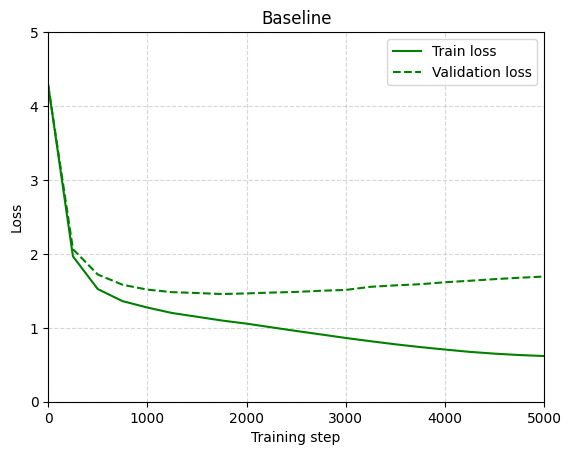

In [85]:
#Plotting the Baseline

plt.plot(df_baseline['step'], df_baseline['train_loss'], label='Train loss', color="green")
plt.plot(df_baseline['step'], df_baseline['val_loss'], label='Validation loss', color="green", ls="--")
plt.xlim(0, 5000)     
plt.ylim(0, 5)
plt.xlabel('Training step')
plt.ylabel('Loss')
plt.title('Baseline')
plt.legend()
plt.grid(True, ls='--', alpha=0.5)
plt.show()

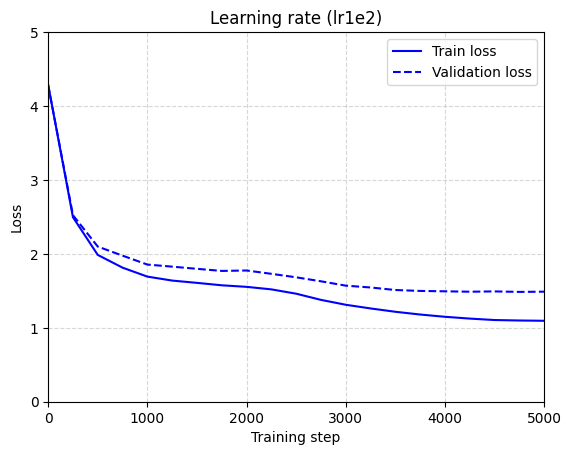

In [84]:
#Plotting lr1e2

plt.plot(df_lr1e2['step'], df_lr1e2['train_loss'], label='Train loss', color="blue")
plt.plot(df_lr1e2['step'], df_lr1e2['val_loss'], label='Validation loss', color="blue", ls="--")
plt.xlim(0, 5000)     
plt.ylim(0, 5)
plt.xlabel('Training step')
plt.ylabel('Loss')
plt.title('Learning rate (lr1e2)')
plt.legend()
plt.grid(True, ls='--', alpha=0.5)
plt.show()

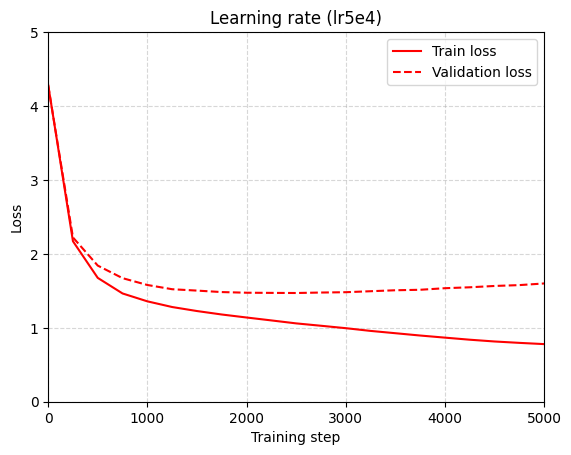

In [83]:
#Plotting lr5e4

plt.plot(df_lr5e4['step'], df_lr5e4['train_loss'], label='Train loss', color="red")
plt.plot(df_lr5e4['step'], df_lr5e4['val_loss'], label='Validation loss', color="red", ls="--")
plt.xlim(0, 5000)     
plt.ylim(0, 5)
plt.xlabel('Training step')
plt.ylabel('Loss')
plt.title('Learning rate (lr5e4)')
plt.legend()
plt.grid(True, ls='--', alpha=0.5)
plt.show()

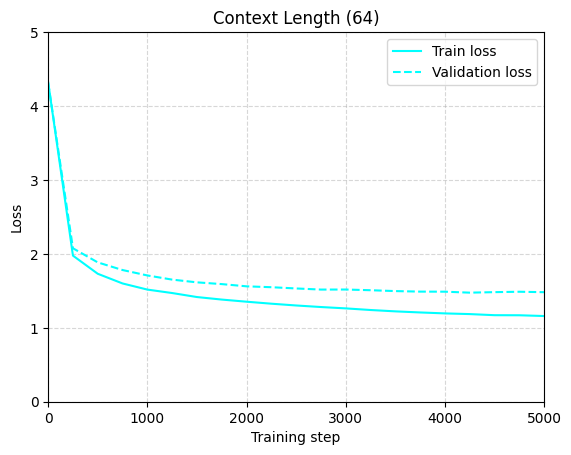

In [82]:
#Plotting the Baseline

plt.plot(df_cl64['step'], df_cl64['train_loss'], label='Train loss', color="cyan")
plt.plot(df_cl64['step'], df_cl64['val_loss'], label='Validation loss', color="cyan", ls="--")
plt.xlim(0, 5000)     
plt.ylim(0, 5)
plt.xlabel('Training step')
plt.ylabel('Loss')
plt.title('Context Length (64)')
plt.legend()
plt.grid(True, ls='--', alpha=0.5)
plt.show()

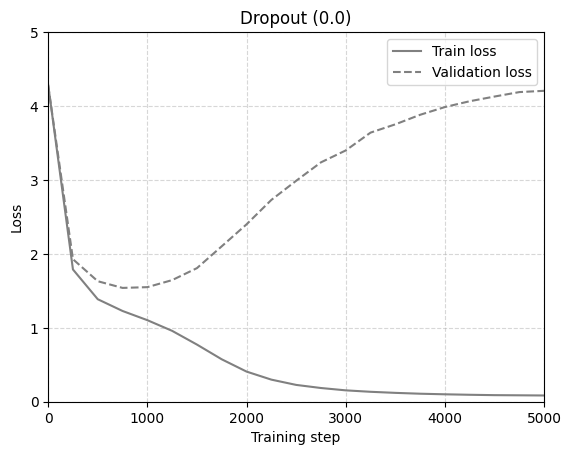

In [81]:
#Plotting Dropout 0.0

plt.plot(df_do00['step'], df_do00['train_loss'], label='Train loss', color="gray")
plt.plot(df_do00['step'], df_do00['val_loss'], label='Validation loss', color="gray", ls="--")
plt.xlim(0, 5000)     
plt.ylim(0, 5)
plt.xlabel('Training step')
plt.ylabel('Loss')
plt.title('Dropout (0.0)')
plt.legend()
plt.grid(True, ls='--', alpha=0.5)
plt.show()

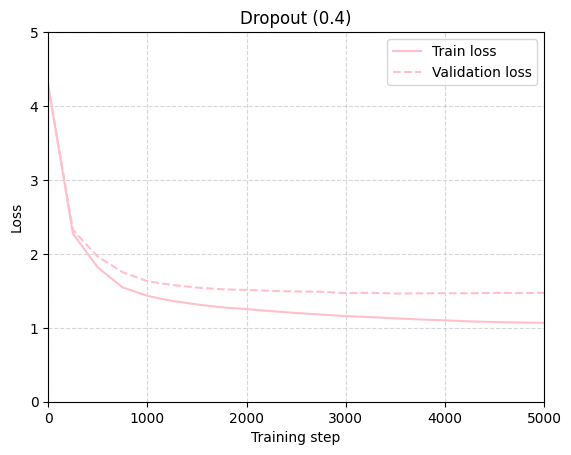

In [80]:
#Plotting Dropout 0.4

plt.plot(df_do04['step'], df_do04['train_loss'], label='Train loss', color="pink")
plt.plot(df_do04['step'], df_do04['val_loss'], label='Validation loss', color="pink", ls="--")
plt.xlim(0, 5000)     
plt.ylim(0, 5)
plt.xlabel('Training step')
plt.ylabel('Loss')
plt.title('Dropout (0.4)')
plt.legend()
plt.grid(True, ls='--', alpha=0.5)
plt.show()

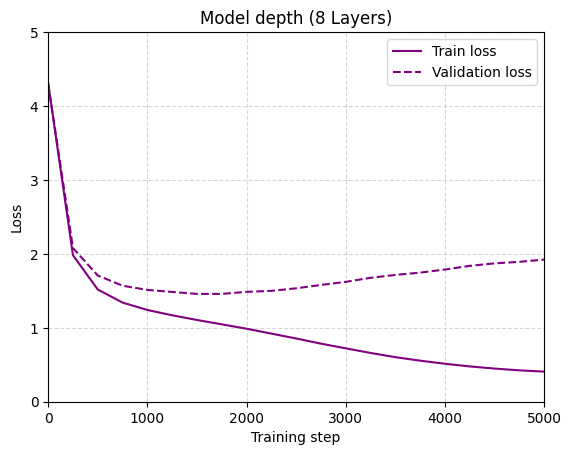

In [78]:
#Plotting Model depth 8

plt.plot(df_md8['step'], df_md8['train_loss'], label='Train loss', color="purple")
plt.plot(df_md8['step'], df_md8['val_loss'], label='Validation loss', color="purple", ls="--")
plt.xlim(0, 5000)     
plt.ylim(0, 5)
plt.xlabel('Training step')
plt.ylabel('Loss')
plt.title('Model depth (8 Layers)')
plt.legend()
plt.grid(True, ls='--', alpha=0.5)
plt.show()

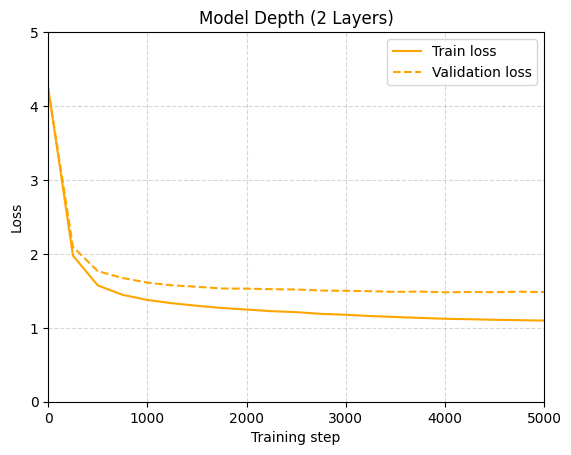

In [79]:
#Plotting Model depth 2

plt.plot(df_md2['step'], df_md2['train_loss'], label='Train loss', color="orange")
plt.plot(df_md2['step'], df_md2['val_loss'], label='Validation loss', color="orange", ls="--")
plt.xlim(0, 5000)     
plt.ylim(0, 5)
plt.xlabel('Training step')
plt.ylabel('Loss')
plt.title('Model Depth (2 Layers)')
plt.legend()
plt.grid(True, ls='--', alpha=0.5)
plt.show()

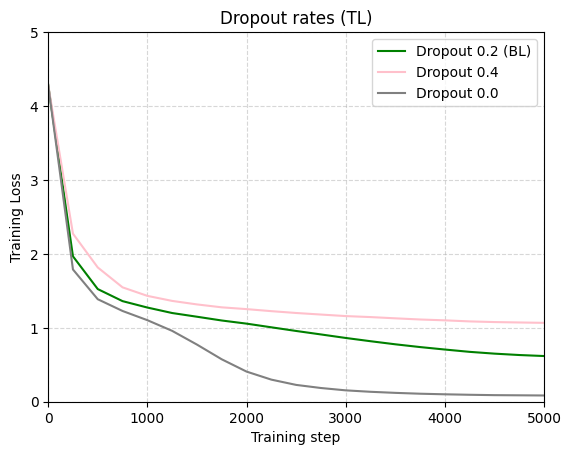

In [76]:
#Plotting Training Loss / change df_names if necessary

plt.plot(df_baseline['step'], df_baseline['train_loss'], label='Dropout 0.2 (BL)', color="green")
plt.plot(df_do04['step'], df_do04['train_loss'], label='Dropout 0.4', color="pink")
plt.plot(df_do00['step'], df_do00['train_loss'], label='Dropout 0.0', color="gray")
plt.xlim(0, 5000)     
plt.ylim(0, 5)
plt.xlabel('Training step')
plt.ylabel('Training Loss')
plt.title('Dropout rates (TL)')
plt.legend()
plt.grid(True, ls='--', alpha=0.5)
plt.show()

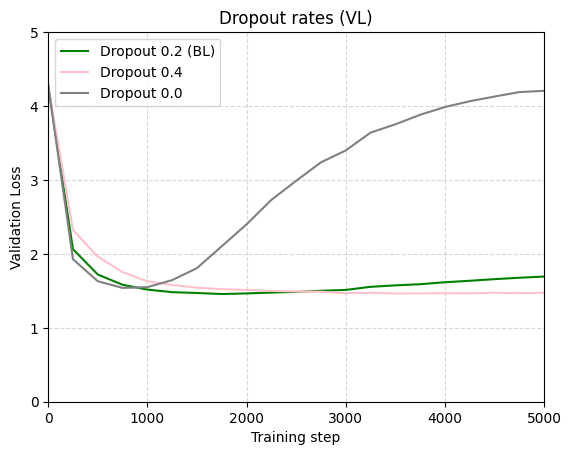

In [75]:
#Plotting Validation Loss / change df_names if necessary

plt.plot(df_baseline['step'], df_baseline['val_loss'], label='Dropout 0.2 (BL)', color="green")
plt.plot(df_do04['step'], df_do04['val_loss'], label='Dropout 0.4', color="pink")
plt.plot(df_do00['step'], df_do00['val_loss'], label='Dropout 0.0', color="gray")
plt.xlim(0, 5000)     
plt.ylim(0, 5)
plt.xlabel('Training step')
plt.ylabel('Validation Loss')
plt.title('Dropout rates (VL)')
plt.legend()
plt.grid(True, ls='--', alpha=0.5)
plt.show()

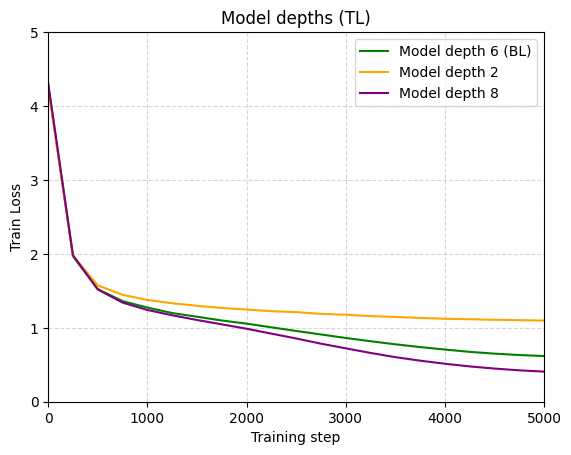

In [74]:
#Plotting Training Loss / change df_names if necessary

plt.plot(df_baseline['step'], df_baseline['train_loss'], label='Model depth 6 (BL)', color="green")
plt.plot(df_md2['step'], df_md2['train_loss'], label='Model depth 2', color="orange")
plt.plot(df_md8['step'], df_md8['train_loss'], label='Model depth 8', color="purple")
plt.xlim(0, 5000)     
plt.ylim(0, 5)
plt.xlabel('Training step')
plt.ylabel('Train Loss')
plt.title('Model depths (TL)')
plt.legend()
plt.grid(True, ls='--', alpha=0.5)
plt.show()

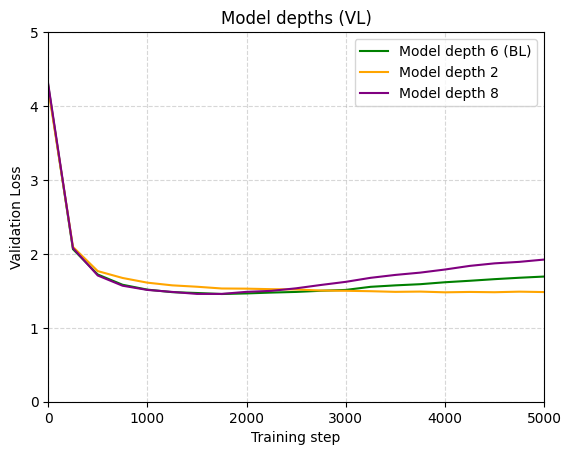

In [73]:
# Plotting Validation Loss / change df_names if necessary

plt.plot(df_baseline['step'], df_baseline['val_loss'], label='Model depth 6 (BL)', color="green")
plt.plot(df_md2['step'], df_md2['val_loss'], label='Model depth 2', color="orange")
plt.plot(df_md8['step'], df_md8['val_loss'], label='Model depth 8', color="purple")
plt.xlim(0, 5000)     
plt.ylim(0, 5)
plt.xlabel('Training step')
plt.ylabel('Validation Loss')
plt.title('Model depths (VL)')
plt.legend()
plt.grid(True, ls='--', alpha=0.5)
plt.show()

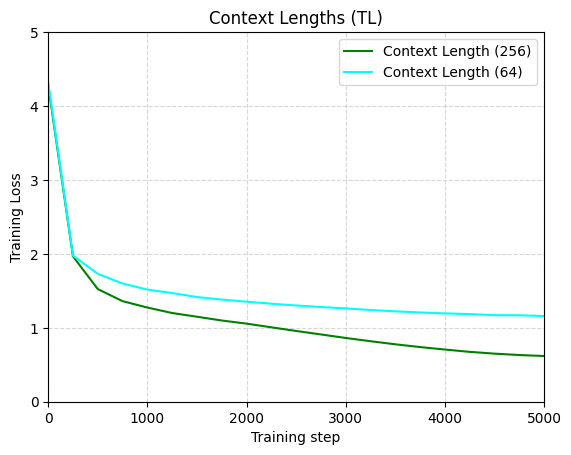

In [72]:
#Plotting Context Lengt / change df_names if necessary

plt.plot(df_baseline['step'], df_baseline['train_loss'], label='Context Length (256)', color="green")
plt.plot(df_cl64['step'], df_cl64['train_loss'], label='Context Length (64)', color="cyan")
plt.xlim(0, 5000)     
plt.ylim(0, 5)
plt.xlabel('Training step')
plt.ylabel('Training Loss')
plt.title('Context Lengths (TL)')
plt.legend()
plt.grid(True, ls='--', alpha=0.5)
plt.show()

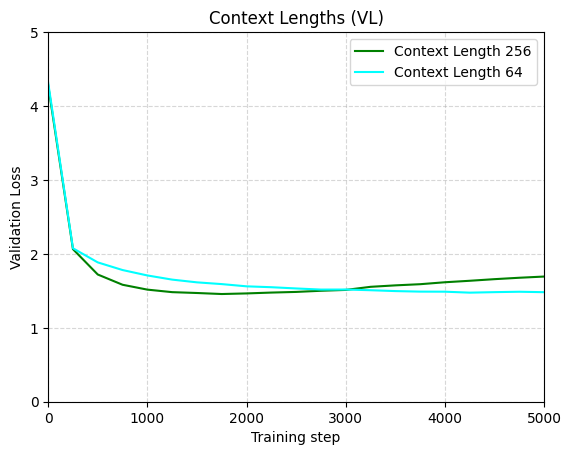

In [71]:
# Plotting Validation Loss / change df_names if necessary

plt.plot(df_baseline['step'], df_baseline['val_loss'], label='Context Length 256', color="green")
plt.plot(df_cl64['step'], df_cl64['val_loss'], label='Context Length 64', color="cyan")
plt.xlim(0, 5000)     
plt.ylim(0, 5)
plt.xlabel('Training step')
plt.ylabel('Validation Loss')
plt.title('Context Lengths (VL)')
plt.legend()
plt.grid(True, ls='--', alpha=0.5)
plt.show()

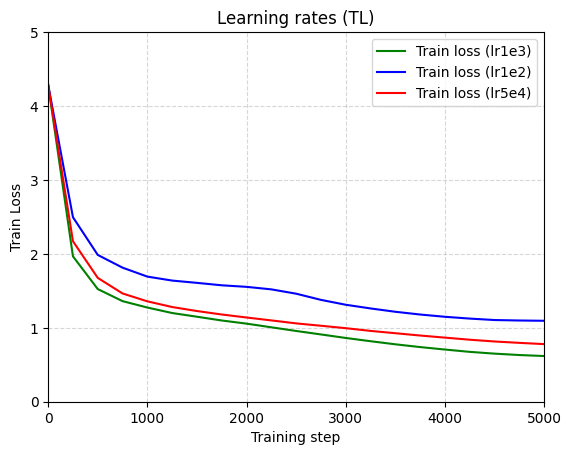

In [64]:
#Plotting Training Loss / change df_names if necessary

plt.plot(df_baseline['step'], df_baseline['train_loss'], label='Train loss (lr1e3)', color="green")
plt.plot(df_lr1e2['step'], df_lr1e2['train_loss'], label='Train loss (lr1e2)', color="blue")
plt.plot(df_lr5e4['step'], df_lr5e4['train_loss'], label='Train loss (lr5e4)', color="red")
plt.xlim(0, 5000)     
plt.ylim(0, 5)
plt.xlabel('Training step')
plt.ylabel('Train Loss')
plt.title('Learning rates (TL)')
plt.legend()
plt.grid(True, ls='--', alpha=0.5)
plt.show()

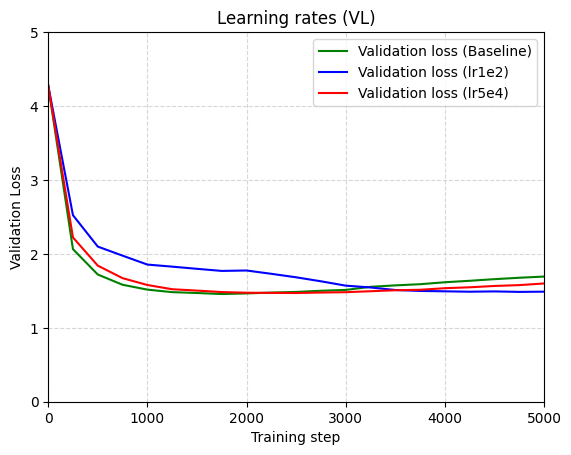

In [65]:
# Plotting Validation Loss / change df_names if necessary

plt.plot(df_baseline['step'], df_baseline['val_loss'], label='Validation loss (Baseline)', color="green")
plt.plot(df_lr1e2['step'], df_lr1e2['val_loss'], label='Validation loss (lr1e2)', color="blue")
plt.plot(df_lr5e4['step'], df_lr5e4['val_loss'], label='Validation loss (lr5e4)', color="red")
plt.xlim(0, 5000)     
plt.ylim(0, 5)
plt.xlabel('Training step')
plt.ylabel('Validation Loss')
plt.title('Learning rates (VL)')
plt.legend()
plt.grid(True, ls='--', alpha=0.5)
plt.show()

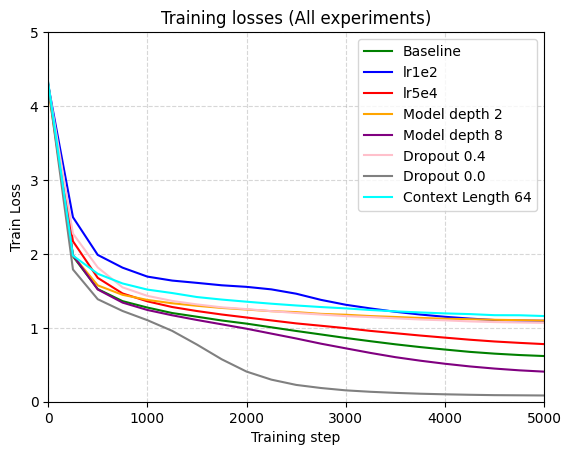

In [87]:
#Plotting Training Loss / change df_names if necessary

plt.plot(df_baseline['step'], df_baseline['train_loss'], label='Baseline', color="green")
plt.plot(df_lr1e2['step'], df_lr1e2['train_loss'], label='lr1e2', color="blue")
plt.plot(df_lr5e4['step'], df_lr5e4['train_loss'], label='lr5e4', color="red")
plt.plot(df_md2['step'], df_md2['train_loss'], label='Model depth 2', color="orange")
plt.plot(df_md8['step'], df_md8['train_loss'], label='Model depth 8', color="purple")
plt.plot(df_do04['step'], df_do04['train_loss'], label='Dropout 0.4', color="pink")
plt.plot(df_do00['step'], df_do00['train_loss'], label='Dropout 0.0', color="gray")
plt.plot(df_cl64['step'], df_cl64['train_loss'], label='Context Length 64', color="cyan")
plt.xlim(0, 5000)     
plt.ylim(0, 5)
plt.xlabel('Training step')
plt.ylabel('Train Loss')
plt.title('Training losses (All experiments)')
plt.legend()
plt.grid(True, ls='--', alpha=0.5)
plt.show()

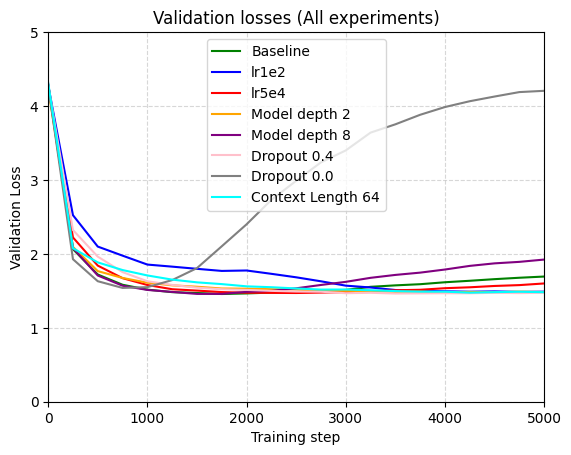

In [89]:
#Plotting Validation Loss / change df_names if necessary

plt.plot(df_baseline['step'], df_baseline['val_loss'], label='Baseline', color="green")
plt.plot(df_lr1e2['step'], df_lr1e2['val_loss'], label='lr1e2', color="blue")
plt.plot(df_lr5e4['step'], df_lr5e4['val_loss'], label='lr5e4', color="red")
plt.plot(df_md2['step'], df_md2['val_loss'], label='Model depth 2', color="orange")
plt.plot(df_md8['step'], df_md8['val_loss'], label='Model depth 8', color="purple")
plt.plot(df_do04['step'], df_do04['val_loss'], label='Dropout 0.4', color="pink")
plt.plot(df_do00['step'], df_do00['val_loss'], label='Dropout 0.0', color="gray")
plt.plot(df_cl64['step'], df_cl64['val_loss'], label='Context Length 64', color="cyan")
plt.xlim(0, 5000)     
plt.ylim(0, 5)
plt.xlabel('Training step')
plt.ylabel('Validation Loss')
plt.title('Validation losses (All experiments)')
plt.legend()
plt.grid(True, ls='--', alpha=0.5)
plt.show()

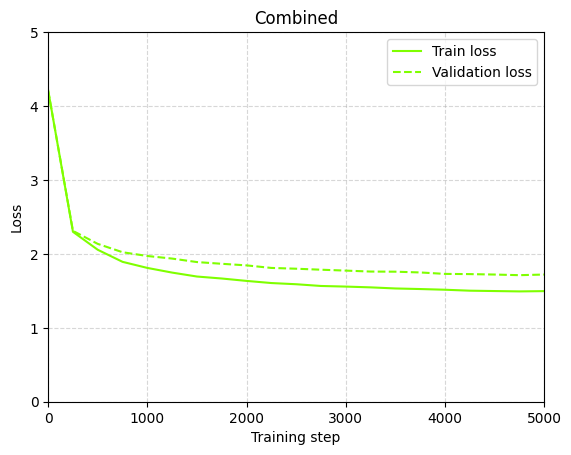

In [29]:
#Plotting the Combined Configuration

plt.plot(df_combineconfig['step'], df_combineconfig['train_loss'], label='Train loss', color="chartreuse")
plt.plot(df_combineconfig['step'], df_combineconfig['val_loss'], label='Validation loss', color="chartreuse", ls="--")
plt.xlim(0, 5000)     
plt.ylim(0, 5)
plt.xlabel('Training step')
plt.ylabel('Loss')
plt.title('Combined')
plt.legend()
plt.grid(True, ls='--', alpha=0.5)
plt.show()

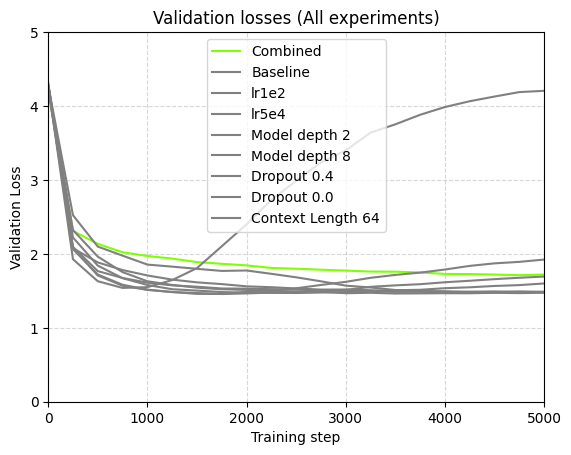

In [30]:
#Comparing our recommendation to the other experiment runs 

plt.plot(df_combineconfig['step'], df_combineconfig['val_loss'], label='Combined', color="chartreuse")
plt.plot(df_baseline['step'], df_baseline['val_loss'], label='Baseline', color="gray")
plt.plot(df_lr1e2['step'], df_lr1e2['val_loss'], label='lr1e2', color="gray")
plt.plot(df_lr5e4['step'], df_lr5e4['val_loss'], label='lr5e4', color="gray")
plt.plot(df_md2['step'], df_md2['val_loss'], label='Model depth 2', color="gray")
plt.plot(df_md8['step'], df_md8['val_loss'], label='Model depth 8', color="gray")
plt.plot(df_do04['step'], df_do04['val_loss'], label='Dropout 0.4', color="gray")
plt.plot(df_do00['step'], df_do00['val_loss'], label='Dropout 0.0', color="gray")
plt.plot(df_cl64['step'], df_cl64['val_loss'], label='Context Length 64', color="gray")
plt.xlim(0, 5000)     
plt.ylim(0, 5)
plt.xlabel('Training step')
plt.ylabel('Validation Loss')
plt.title('Validation losses (All experiments)')
plt.legend()
plt.grid(True, ls='--', alpha=0.5)
plt.show()

#### 4.3 Creating a table

In [48]:
# Installing new dependencies to create a nice table

!pip install plotly
!pip install kaleido

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.9 MB 2.8 MB/s eta 0:00:04
   ------ --------------------------------- 1.6/9.9 MB 4.2 MB/s eta 0:00:02
   ---------------- ----------------------- 4.2/9.9 MB 7.2 MB/s eta 0:00:01
   --------------------------------- ------ 8.4/9.9 MB 10.6 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 11.2 MB/s  0:00:00

   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   -------------------- ------------------- 1/2 [plotly]
   -------------------- ------------------- 1/2 [plotly]
   -------------------- ------------------- 1/2 [plotly]
   -------------------- --

In [91]:
#Importing necessary libraries

import matplotlib.pyplot as plt
import pandas as pd
from pandas.plotting import table
import plotly.figure_factory as ff

In [94]:
#Creating a Dataframe for Results (hand-filled)

df_table = pd.DataFrame(
    {"Experiment": ["Baseline", "Low LR", "High LR", "No Dropout", "High Dropout", "High Model Depth", "Low Model Depth", "Short Context Length"], "LR": ["1e-3", "5e-4", "1e-2", "1e-3", "1e-3", "1e-3", "1e-3", "1e-3"], "Layers": ["6", "6", "6", "6", "6", "8", "2", "6"], "Embd": ["384", "384", "384", "384", "384", "384", "384", "384"], "Block": ["256", "256", "256", "256", "256", "256", "256", "64"], "Dropout": ["0.2", "0.2", "0.2", "0.0", "0.4", "0.2", "0.2", "0.2"], "Iters": ["5000", "5000", "5000", "5000", "5000", "5000", "5000", "5000"], "Train Loss": ["0.6180", "0.7794", "1.0950", "0.0844", "1.0669", "0.4070", "1.0974", "1.1592"], "Val Loss": ["1.6934", "1.5999", "1.4887", "4.2060", "1.4739", "1.9232", "1.4834", "1.4817"], "Time (min)": ["20.48", "21.74", "19.94", "132.40", "20.23", "25.99", "7.70", "5.63"]},
)
df_table.style.format(precision=4, thousands=".", decimal=",").format_index(
    str.upper, axis=1
).relabel_index(["Baseline", "Low LR", "High LR", "No Dropout", "High Dropout", "High Model Depth", "Low Model Depth", "Short Context Length"], axis=0)

,EXPERIMENT,LR,LAYERS,EMBD,BLOCK,DROPOUT,ITERS,TRAIN LOSS,VAL LOSS,TIME (MIN)
Baseline,Baseline,1e-3,6,384,256,0.2,5000,0.6180,1.6934,20.48
Low LR,Low LR,5e-4,6,384,256,0.2,5000,0.7794,1.5999,21.74
High LR,High LR,1e-2,6,384,256,0.2,5000,1.0950,1.4887,19.94
No Dropout,No Dropout,1e-3,6,384,256,0.0,5000,0.0844,4.2060,132.40
High Dropout,High Dropout,1e-3,6,384,256,0.4,5000,1.0669,1.4739,20.23
High Model Depth,High Model Depth,1e-3,8,384,256,0.2,5000,0.4070,1.9232,25.99
Low Model Depth,Low Model Depth,1e-3,2,384,256,0.2,5000,1.0974,1.4834,7.70
Short Context Length,Short Context Length,1e-3,6,384,64,0.2,5000,1.1592,1.4817,5.63
